In [ ]:
# Download data from Zenodo (skip if already downloaded)
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'scripts'))
from download_data import download_all
from config import DATA_ROOT

if not os.path.exists(os.path.join(DATA_ROOT, 'summary_stats.h5')):
    download_all()
else:
    print(f'Data already present at {DATA_ROOT}')

In [1]:
import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), '..', 'scripts'))

import numpy as np
import pandas as pd
import h5py
import pickle
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
from formatting import COLORS, initialize_latex
from config import DATA_ROOT

%matplotlib inline
initialize_latex()

In [2]:
# 9 events shown in Figure 4
NINE_EVENTS = [
    'GW230706_104333',
    'GW230709_122727',
    'GW230820_212515',
    'GW231001_140220',
    'GW231114_043211',
    'GW231221_135041',
    'GW231223_032836',
    'GW231224_024321',
    'GW240104_164932',
]

# Load posteriors from HDF5
posteriors = {}
ecc_path = os.path.join(DATA_ROOT, 'posteriors_ecc.h5')
for event in NINE_EVENTS:
    posteriors[event] = pd.read_hdf(ecc_path, key=f'{event}/posterior')
    print(f'  {event}: {len(posteriors[event])} samples')

# Load prior hull data
prior_path = os.path.join(DATA_ROOT, 'prior_samples.h5')
with open(prior_path.replace('.h5', '.pkl'), 'rb') as f:
    results_2d = pickle.load(f)

  GW230706_104333: 3200000 samples
  GW230709_122727: 13214 samples
  GW230820_212515: 250000 samples
  GW231001_140220: 14260 samples
  GW231114_043211: 14819 samples
  GW231221_135041: 750000 samples
  GW231223_032836: 250000 samples
  GW231224_024321: 15275 samples
  GW240104_164932: 11505 samples


In [3]:
def chirp_mass_and_mass_ratio_to_total_mass(chirp_mass, mass_ratio):
    """Convert chirp mass and mass ratio to total mass."""
    m1 = chirp_mass * (1 + mass_ratio) ** (1/5) / mass_ratio ** (3/5)
    return m1 * (1 + mass_ratio)

def get_polygon_contours(total_mass, results_2d):
    for result in results_2d:
        if result['bin_low'] <= total_mass < result['bin_high']:
            x, y = result['generateable_hull'].exterior.xy
            return x, y

def extract_right_boundary(x, y,
                           x_left_thresh=0.02,
                           y_bottom_thresh=0.02,
                           y_top_thresh=2*np.pi - 0.02):
    x, y = np.asarray(x), np.asarray(y)
    flat_mask = (x < x_left_thresh) | (y < y_bottom_thresh) | (y > y_top_thresh)
    xr, yr = x[~flat_mask], y[~flat_mask]
    order = np.argsort(yr)
    return xr[order], yr[order]

def make_band_between_curves_lr(y_upper, x_upper, y_lower, x_lower, num=400):
    order_up = np.argsort(y_upper)
    order_lo = np.argsort(y_lower)
    y_upper, x_upper = np.asarray(y_upper)[order_up], np.asarray(x_upper)[order_up]
    y_lower, x_lower = np.asarray(y_lower)[order_lo], np.asarray(x_lower)[order_lo]
    y_min = max(y_upper.min(), y_lower.min())
    y_max = min(y_upper.max(), y_lower.max())
    y_grid = np.linspace(y_min, y_max, num)
    f_up = interp1d(y_upper, x_upper, bounds_error=False, fill_value='extrapolate')
    f_lo = interp1d(y_lower, x_lower, bounds_error=False, fill_value='extrapolate')
    return y_grid, f_up(y_grid), f_lo(y_grid)

def get_bands(posterior_samples):
    total_mass = chirp_mass_and_mass_ratio_to_total_mass(
        posterior_samples['chirp_mass'].values,
        posterior_samples['mass_ratio'].values
    )
    total_mass_upper = np.percentile(total_mass, 95)
    total_mass_lower = np.percentile(total_mass, 5)
    hull_x_upper, hull_y_upper = get_polygon_contours(total_mass_upper, results_2d)
    hull_x_lower, hull_y_lower = get_polygon_contours(total_mass_lower, results_2d)
    xr_up, yr_up = extract_right_boundary(hull_x_upper, hull_y_upper)
    xr_lo, yr_lo = extract_right_boundary(hull_x_lower, hull_y_lower)
    return make_band_between_curves_lr(yr_up, xr_up, yr_lo, xr_lo)

/tmp/ipykernel_2915721/182166030.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


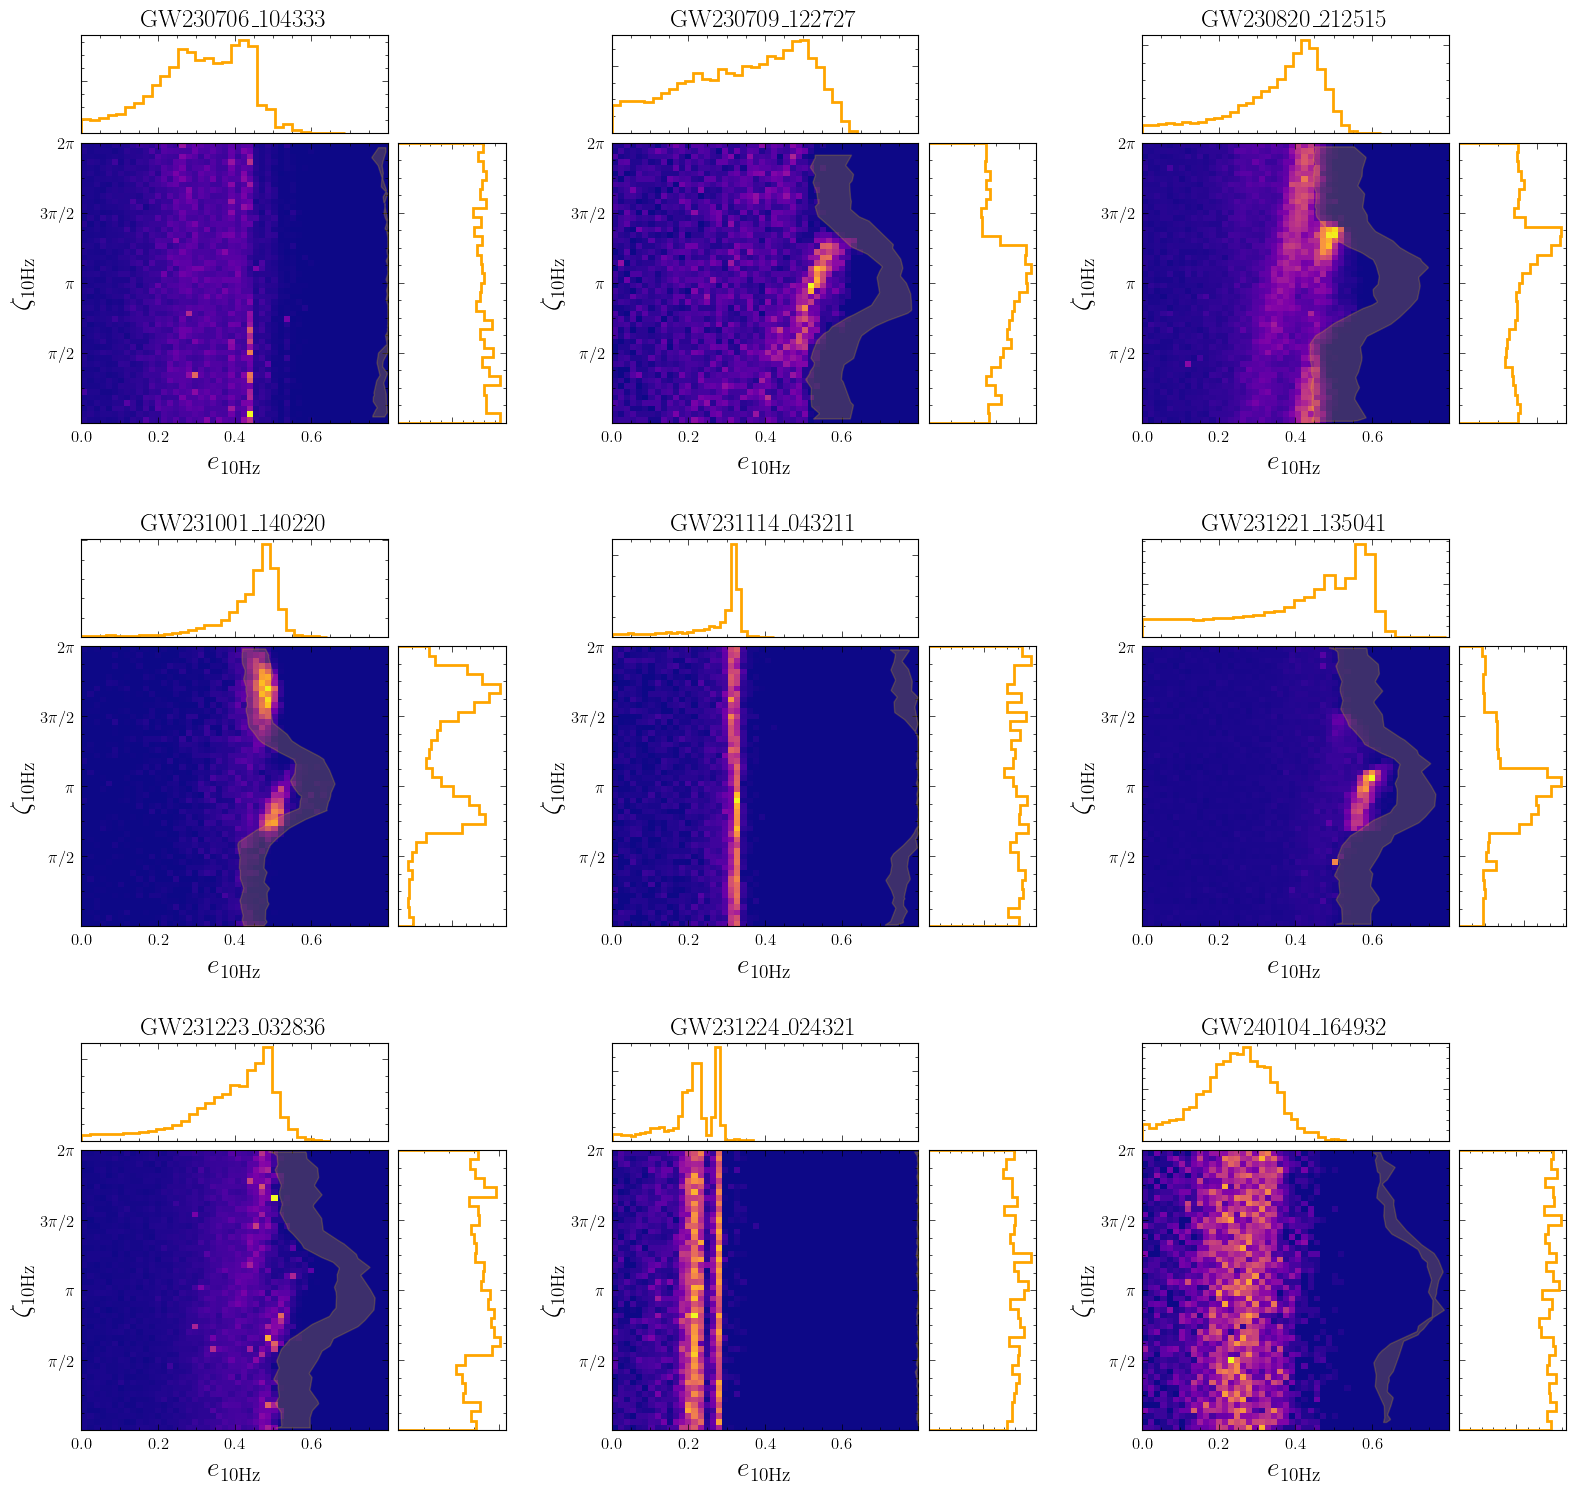

In [4]:
def sampling_importance_resampling(df):
    """Resample a DataFrame according to importance weights."""
    if 'weights' not in df.columns:
        return df
    w = df['weights'].values
    w = w / w.sum()
    idx = np.random.choice(len(df), size=len(df), p=w, replace=True)
    return df.iloc[idx].reset_index(drop=True)


def plot_posteriors_grid(posteriors):
    events = list(posteriors.keys())
    N = len(events)
    ncols = 3
    nrows = int(np.ceil(N / ncols))

    fig = plt.figure(figsize=(6*ncols, 6*nrows))
    gs = fig.add_gridspec(nrows, ncols, wspace=0.25, hspace=0.3)

    for i, event in enumerate(events):
        posterior = sampling_importance_resampling(posteriors[event])
        row, col = i // ncols, i % ncols

        sub_gs = gs[row, col].subgridspec(
            2, 2, height_ratios=[0.35, 1.0], width_ratios=[1.0, 0.35],
            hspace=0.05, wspace=0.05
        )
        ax_post = fig.add_subplot(sub_gs[1, 0])
        ax_marg_x = fig.add_subplot(sub_gs[0, 0], sharex=ax_post)
        ax_marg_y = fig.add_subplot(sub_gs[1, 1], sharey=ax_post)

        x = posterior['eccentricity'].values
        y = posterior['mean_anomaly'].values

        # Prior boundary band
        try:
            yg, xg_up, xg_lo = get_bands(posterior)
            ax_post.fill_betweenx(yg, xg_lo, xg_up, color=COLORS['yellow'],
                                  alpha=0.2, zorder=5, label='prior boundary')
        except Exception:
            pass

        # 2D posterior histogram
        x_bins = np.linspace(0, 0.8, 51)
        y_bins = np.linspace(0, 2*np.pi, 51)
        H, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins], density=True)
        X, Y = np.meshgrid(xedges, yedges)
        ax_post.pcolormesh(X, Y, H.T, cmap='plasma', shading='flat')

        ax_post.set_xlabel('$e_{\\mathrm{10Hz}}$', fontsize=20)
        ax_post.set_ylabel('$\\zeta_{\\mathrm{10Hz}}$', fontsize=20)
        ax_post.set_xticks([0, 0.2, 0.4, 0.6])
        ax_post.set_yticks(
            [np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
            labels=[r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
        )
        ax_post.tick_params(axis='both', rotation=0)

        # Marginals
        ax_marg_x.hist(x, bins=30, density=True, histtype='step', color='orange', linewidth=2)
        ax_marg_y.hist(y, bins=30, density=True, orientation='horizontal',
                       histtype='step', color='orange', linewidth=2)

        ax_marg_x.tick_params(labelbottom=False, labelleft=False)
        ax_marg_y.tick_params(labelbottom=False, labelleft=False)
        for ax in [ax_marg_x, ax_marg_y, ax_post]:
            ax.grid(False)
            ax.tick_params(axis='x', rotation=0)
            ax.tick_params(axis='y', rotation=0)

        ax_marg_x.set_title(event, fontsize=18)

    plt.tight_layout()
    plt.savefig('../figures/posterior_grid.pdf', dpi=300, bbox_inches='tight')


plot_posteriors_grid(posteriors)